# Projet Probabilistic Graphical Model - NOT-MIWAE Vs MIWAE

### Run this if you work on Colab

In [1]:
# Run if destination doesn't already exists
!git clone https://github.com/VincentGefflaut/notMIWAE-project.git

Cloning into 'notMIWAE-project'...
remote: Enumerating objects: 75, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 75 (delta 31), reused 35 (delta 19), pack-reused 19 (from 1)
Receiving objects: 100% (75/75), 595.68 KiB | 2.80 MiB/s, done.
Resolving deltas: 100% (39/39), done.


In [5]:
# Always run before working in Colab
import sys
sys.path.insert(0,'/content/notMIWAE-project')
!cd notMIWAE-project; git pull

Already up to date.


In [6]:
# Add path_prefix before all paths
path_prefix = '/content/notMIWAE-project/'

Chargement de White...

--- Dataset: White | Modèle: MIWAE ---
Creating graph...
Saving session...
Saving session...
0/50000 updates, 3.50 s, 12.69 train_loss, 17.08 val_loss
Saving session...
100/50000 updates, 0.53 s, 8.46 train_loss, 15.53 val_loss
200/50000 updates, 0.43 s, 19.51 train_loss, 22.90 val_loss
300/50000 updates, 0.40 s, 8.63 train_loss, 26.95 val_loss
400/50000 updates, 0.41 s, 8.75 train_loss, 27.57 val_loss
500/50000 updates, 0.41 s, 7.28 train_loss, 28.68 val_loss
600/50000 updates, 0.44 s, 9.17 train_loss, 29.91 val_loss
700/50000 updates, 0.64 s, 8.01 train_loss, 31.11 val_loss
800/50000 updates, 0.61 s, 9.72 train_loss, 28.85 val_loss
900/50000 updates, 0.68 s, 8.32 train_loss, 33.03 val_loss
1000/50000 updates, 0.47 s, 8.08 train_loss, 33.70 val_loss
1100/50000 updates, 0.41 s, 9.37 train_loss, 31.09 val_loss
1200/50000 updates, 0.42 s, 10.09 train_loss, 31.34 val_loss
1300/50000 updates, 0.40 s, 7.61 train_loss, 30.08 val_loss
1400/50000 updates, 0.39 s, 8.76 t

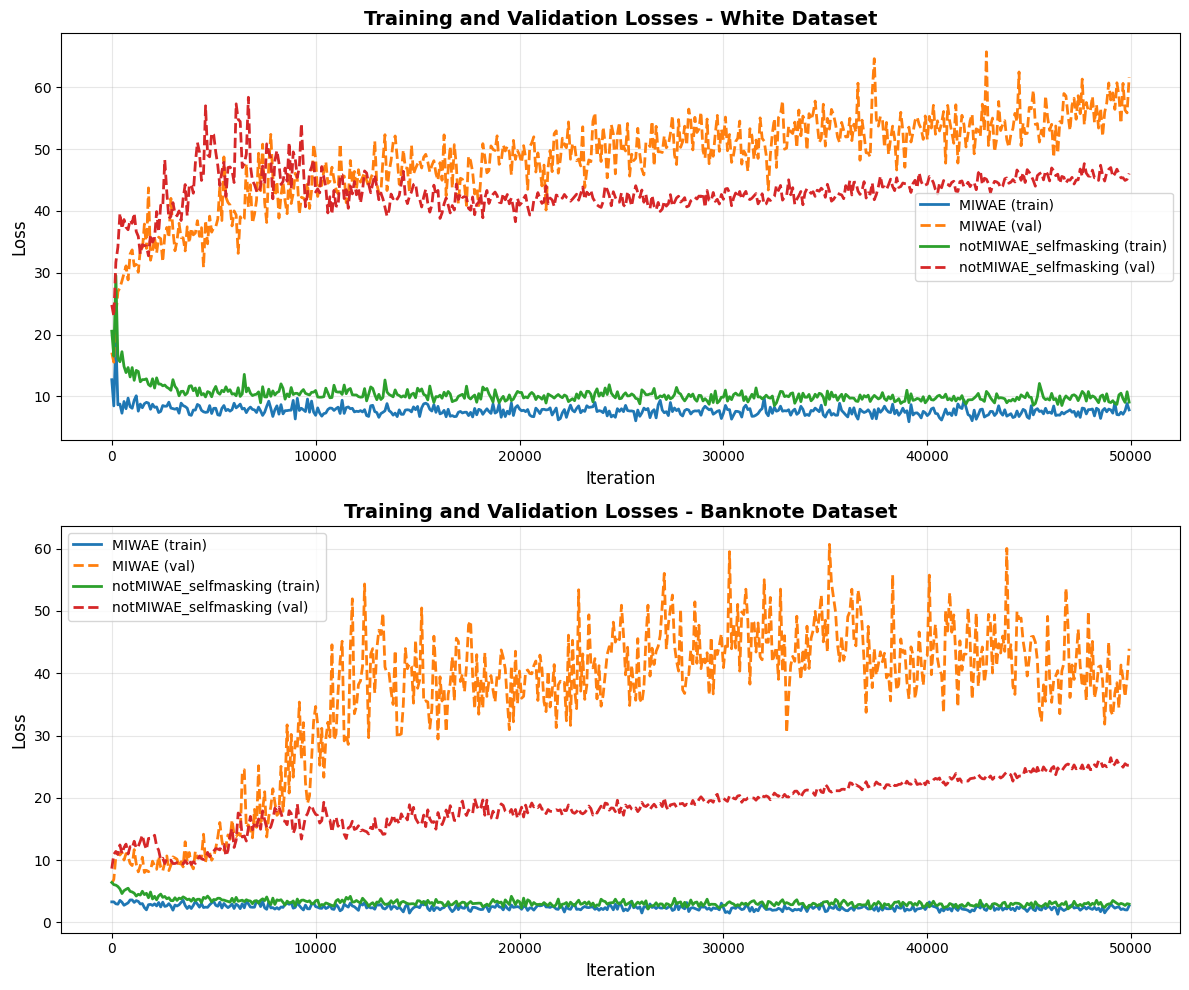

Plots generated successfully!


In [7]:
import numpy as np
import pandas as pd
import tensorflow.compat.v1 as tf
# tf.disable_eager_execution() # Déjà géré par notre patch sed, mais sécurité
import os
import sys
import matplotlib.pyplot as plt

# Imports du repo local
from MIWAE import MIWAE
from notMIWAE import notMIWAE
import trainer
import utils

from sklearn.preprocessing import StandardScaler

# --- Fonctions de chargement et préparation ---

def load_uci_data(dataset_name):
    """Charge les datasets via les URLs UCI."""
    print(f"Chargement de {dataset_name}...")
    if dataset_name == 'White':
        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"
        data = pd.read_csv(url, sep=';').values
    elif dataset_name == 'Red':
        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
        data = pd.read_csv(url, sep=';').values
    elif dataset_name == 'Banknote':
        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
        data = pd.read_csv(url, header=None).values
    elif dataset_name == 'Concrete':
        # Concrete nécessite souvent openpyxl
        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"
        try:
            data = pd.read_excel(url).values
        except:
            print("Erreur chargement Excel Concrete. Installation dépendance...")
            os.system('pip install xlrd')
            data = pd.read_excel(url).values
    else:
        raise ValueError("Dataset non supporté dans ce script demo.")
    return data

def introduce_mnar_missing(X):
    """
    Simule le mécanisme MNAR (Self-masking) décrit dans l'article.
    Si la valeur > moyenne de la colonne, elle devient manquante.
    Appliqué sur la moitié des colonnes.
    """
    N, D = X.shape
    Xnan = X.copy()
    n_missing_cols = int(D / 2)

    # Calcul des moyennes par colonne
    means = np.mean(Xnan[:, :n_missing_cols], axis=0)

    # Création du masque (True = Manquant)
    mask_condition = Xnan[:, :n_missing_cols] > means

    # Application des NaN
    Xnan[:, :n_missing_cols][mask_condition] = np.nan

    # Version avec 0 à la place des NaN (pour l'input réseau)
    Xz = Xnan.copy()
    Xz[np.isnan(Xnan)] = 0

    return Xnan, Xz

# --- Paramètres de l'expérience (Tableau 1) ---

# Pour tester rapidement que tout marche, on réduit les itérations.
# Pour le VRAI résultat, mettez max_iter = 50000 ou 100000
MAX_ITER = 50000
BATCH_SIZE = 16
N_SAMPLES = 20
L_IMP = 500 # Échantillons pour l'imputation finale

# Liste des datasets à tester (Commencez par 'White' pour tester)
DATASETS = ['White', 'Banknote']

# Liste des modèles
MODELS = ['MIWAE', 'notMIWAE_selfmasking']

results = []
loss_histories = {}  # Store loss histories for plotting

for dataset in DATASETS:
    try:
        # 1. Préparation Données
        data = load_uci_data(dataset)
        # On enlève la dernière colonne (target/class) comme dans task01.py
        data = data[:, :-1]

        N, D = data.shape
        dl = D - 1 # Dimension latente

        # Standardisation (Centrer-Réduire)
        scaler = StandardScaler()
        data = scaler.fit_transform(data)

        # Shuffle
        np.random.seed(42)
        p = np.random.permutation(N)
        data = data[p, :]

        Xtrain = data.copy()

        # Création des manques
        Xnan, Xz = introduce_mnar_missing(Xtrain)
        S = np.array(~np.isnan(Xnan), dtype=np.float32)

        # Pour simplifier, Xval = Xtrain ici (juste pour monitoring)
        Xval = Xtrain

        # 2. Entrainement des modèles
        for model_name in MODELS:
            tf.reset_default_graph() # Nettoyage mémoire TF
            sess_name = f"/tmp/{dataset}_{model_name}"

            print(f"\n--- Dataset: {dataset} | Modèle: {model_name} ---")

            if model_name == 'MIWAE':
                model = MIWAE(Xnan, Xval, n_latent=dl, n_samples=N_SAMPLES,
                              n_hidden=128, name=sess_name)
                history = trainer.train(model, batch_size=BATCH_SIZE, max_iter=MAX_ITER, name=sess_name)
                # Calcul RMSE
                rmse = utils.imputationRMSE(model, Xtrain, Xz, Xnan, S, L_IMP)[0]

            elif 'notMIWAE' in model_name:
                # Choix du processus (linear=agnostic, selfmasking, etc.)
                proc = 'linear' if 'agnostic' in model_name else 'selfmasking'
                if 'known' in model_name: proc = 'selfmasking_known'

                model = notMIWAE(Xnan, Xval, n_latent=dl, n_samples=N_SAMPLES,
                                 n_hidden=128, missing_process=proc, name=sess_name)
                history = trainer.train(model, batch_size=BATCH_SIZE, max_iter=MAX_ITER, name=sess_name)
                # Calcul RMSE
                rmse = utils.not_imputationRMSE(model, Xtrain, Xz, Xnan, S, L_IMP)[0]

            # Store loss history for plotting
            loss_histories[f"{dataset}_{model_name}"] = history

            print(f"Résultat -> RMSE: {rmse:.4f}")
            results.append({'Dataset': dataset, 'Model': model_name, 'RMSE': rmse})

    except Exception as e:
        print(f"Erreur sur {dataset}: {e}")

print("\n=== RÉSULTATS FINAUX ===")
df = pd.DataFrame(results)
print(df)

# --- Plot training curves ---
print("\n=== PLOTTING TRAINING CURVES ===")

# Create a figure with subplots for each dataset
datasets_used = list(set([key.split('_')[0] for key in loss_histories.keys()]))
fig, axes = plt.subplots(len(datasets_used), 1, figsize=(12, 5*len(datasets_used)))

if len(datasets_used) == 1:
    axes = [axes]

for idx, dataset in enumerate(datasets_used):
    ax = axes[idx]

    for model_name in MODELS:
        key = f"{dataset}_{model_name}"
        if key in loss_histories:
            history = loss_histories[key]
            iterations = history['iterations']
            train_losses = history['train_losses']
            val_losses = history['val_losses']

            # Plot train and val losses
            ax.plot(iterations, train_losses, label=f'{model_name} (train)', linestyle='-', linewidth=2)
            ax.plot(iterations, val_losses, label=f'{model_name} (val)', linestyle='--', linewidth=2)

    ax.set_xlabel('Iteration', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title(f'Training and Validation Losses - {dataset} Dataset', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Plots generated successfully!")

# Explications

Le script `reproduce_table1.py` que nous avons créé est un **chef d'orchestre** : il ne contient pas la logique mathématique profonde des modèles, il se contente d'importer et d'utiliser les scripts originaux du GitHub que vous voyez dans votre capture d'écran.

Voici précisément comment `reproduce_table1.py` utilise les fichiers du dossier `notMIWAE` :

### 1\. Les Modèles (`MIWAE.py` et `notMIWAE.py`)

Dans `reproduce_table1.py`, les lignes suivantes chargent l'architecture des réseaux de neurones :

In [ ]:
from MIWAE import MIWAE
from notMIWAE import notMIWAE

* **`MIWAE.py`** : Fournit la classe `MIWAE`. Le script l'utilise pour créer le modèle de base (Encodeur/Décodeur gaussien).
  * **`notMIWAE.py`** : Fournit la classe `notMIWAE`. C'est ici que se trouve toute la logique spécifique à l'article, notamment le **mécanisme de données manquantes** (`missing_process='selfmasking'`) qui permet d'apprendre le lien entre la valeur d'une donnée et le fait qu'elle soit manquante.

### 2\. L'Entraînement (`trainer.py`)

Le script de reproduction appelle :

In [ ]:
import trainer
...
trainer.train(model, batch_size=BATCH_SIZE, ...)

* Il utilise **`utils.py`** pour faire l'imputation. C'est ce fichier qui contient les formules mathématiques complexes (Importance Sampling) pour estimer les valeurs manquantes proprement, comme décrit dans l'annexe de l'article.

### En résumé

Votre script `reproduce_table1.py` n'a fait que **préparer les données** (charger les vins, créer les trous MNAR) et **appeler les fonctions** qui étaient déjà codées dans les fichiers du GitHub.

C'est pour cela que nous avons dû appliquer les correctifs (`sed ...`) sur `MIWAE.py`, `notMIWAE.py`, `trainer.py` et `utils.py` avant de lancer le tout : si ces fichiers originaux avaient planté, votre script de reproduction aurait planté aussi puisqu'il dépend entièrement d'eux.

# Task
The training of the MIWAE and notMIWAE models on the 'White' and 'Banknote' datasets has been completed. The models were evaluated based on the Root Mean Squared Error (RMSE) for imputation of missing values, where missingness was introduced using a self-masking (MNAR) mechanism.

Here are the final RMSE results:

```
    Dataset                 Model      RMSE
0     White                 MIWAE  1.630804
1     White  notMIWAE_selfmasking  1.478524
2  Banknote                 MIWAE  1.320324
3  Banknote  notMIWAE_selfmasking  1.029433
```